In [3]:
# ==========================================================
# 03_data_quality_degradation_MAR_randomForest.py
# Full Dataset MAR + KNN + Random Forest
# ==========================================================

import pandas as pd
import numpy as np
import os
import shap

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# ----------------------------------------------------------
# 1. Load Dataset
# ----------------------------------------------------------
file_path = "../dataset/clean_dengue_dataset.csv"
df = pd.read_csv(file_path)

target_column = "dengue_label"

X = df.drop(columns=[target_column])
y = df[target_column]

feature_names = X.columns.tolist()

# ----------------------------------------------------------
# 2. Train-Test Split
# ----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

# ----------------------------------------------------------
# 3. Output Folders
# ----------------------------------------------------------
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/plots", exist_ok=True)

In [4]:
# ----------------------------------------------------------
# 4. Full Dataset MAR Function
# ----------------------------------------------------------
def inject_mar_missingness(df_input, level, random_state=42):

    np.random.seed(random_state)

    df_missing = df_input.copy()
    n = len(df_missing)

    for i in range(n):

        if pd.notnull(df_missing.loc[i, "age"]):
            if df_missing.loc[i, "age"] > 50:
                if np.random.rand() < level:
                    df_missing.loc[i, "hemoglobin_g_dl"] = np.nan

        if pd.notnull(df_missing.loc[i, "platelet_count"]):
            if df_missing.loc[i, "platelet_count"] < 80000:
                if np.random.rand() < level:
                    df_missing.loc[i, "wbc_count"] = np.nan

        if df_missing.loc[i, "gender"] == 1:
            if np.random.rand() < level:
                df_missing.loc[i, "rbc_count"] = np.nan

        if df_missing.loc[i, "gender"] == 2:
            if np.random.rand() < level:
                df_missing.loc[i, "age"] = np.nan

        if pd.notnull(df_missing.loc[i, "wbc_count"]):
            if df_missing.loc[i, "wbc_count"] < 3000:
                if np.random.rand() < level:
                    df_missing.loc[i, "differential_count"] = np.nan

        if pd.notnull(df_missing.loc[i, "hemoglobin_g_dl"]):
            if df_missing.loc[i, "hemoglobin_g_dl"] < 12:
                if np.random.rand() < level:
                    df_missing.loc[i, "platelet_count"] = np.nan

        if pd.notnull(df_missing.loc[i, "platelet_distribution_width"]):
            if df_missing.loc[i, "platelet_distribution_width"] > 16:
                if np.random.rand() < level:
                    df_missing.loc[i, "rbc_count"] = np.nan

        if pd.notnull(df_missing.loc[i, "age"]):
            if df_missing.loc[i, "age"] < 18:
                if np.random.rand() < level:
                    df_missing.loc[i, "platelet_distribution_width"] = np.nan

    return df_missing

# ----------------------------------------------------------
# 5. MAR Levels
# ----------------------------------------------------------
mar_levels = [0.05, 0.10, 0.20, 0.30, 0.4, 0.5, 0.6, 0.7, 0.8]

results = []
stored_models = {}

# ----------------------------------------------------------
# 6. Loop Through Levels
# ----------------------------------------------------------
for level in mar_levels:

    print("=" * 60)
    print(f"Running MAR Level: {int(level*100)}%")
    print("=" * 60)

    # Inject MAR missingness
    X_train_mar = inject_mar_missingness(X_train, level)

    missing_count = X_train_mar.isnull().sum().sum()

    # KNN Imputation
    imputer = KNNImputer(n_neighbors=5)

    X_train_imp = imputer.fit_transform(X_train_mar)
    X_test_imp = imputer.transform(X_test)

    # Train Random Forest
    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_imp, y_train)

    # Predictions
    y_pred = model.predict(X_test_imp)
    y_prob = model.predict_proba(X_test_imp)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    print(f"Missing Values : {missing_count}")
    print(f"Accuracy       : {acc:.4f}")
    print(f"F1 Score       : {f1:.4f}")
    print(f"ROC AUC        : {roc:.4f}")

    results.append({
        "MAR_Level": int(level * 100),
        "Missing_Values": missing_count,
        "Accuracy": acc,
        "F1_Score": f1,
        "ROC_AUC": roc
    })

    stored_models[level] = {
        "model": model,
        "X_test_imp": X_test_imp
    }

# ----------------------------------------------------------
# 7. Save Results
# ----------------------------------------------------------
results_df = pd.DataFrame(results)

results_df.to_csv(
    "outputs/randomForest_MAR_results.csv",
    index=False
)

print("\nResults saved successfully.")

Running MAR Level: 5%
Missing Values : 146
Accuracy       : 0.9242
F1 Score       : 0.9425
ROC AUC        : 0.9028
Running MAR Level: 10%
Missing Values : 248
Accuracy       : 0.9343
F1 Score       : 0.9502
ROC AUC        : 0.9138
Running MAR Level: 20%
Missing Values : 432
Accuracy       : 0.9242
F1 Score       : 0.9425
ROC AUC        : 0.9196
Running MAR Level: 30%
Missing Values : 593
Accuracy       : 0.9242
F1 Score       : 0.9425
ROC AUC        : 0.9082
Running MAR Level: 40%
Missing Values : 744
Accuracy       : 0.9242
F1 Score       : 0.9430
ROC AUC        : 0.9062
Running MAR Level: 50%
Missing Values : 881
Accuracy       : 0.9293
F1 Score       : 0.9466
ROC AUC        : 0.9118
Running MAR Level: 60%
Missing Values : 1003
Accuracy       : 0.9293
F1 Score       : 0.9466
ROC AUC        : 0.9184
Running MAR Level: 70%
Missing Values : 1159
Accuracy       : 0.9242
F1 Score       : 0.9425
ROC AUC        : 0.9124
Running MAR Level: 80%
Missing Values : 1250
Accuracy       : 0.9293
F1

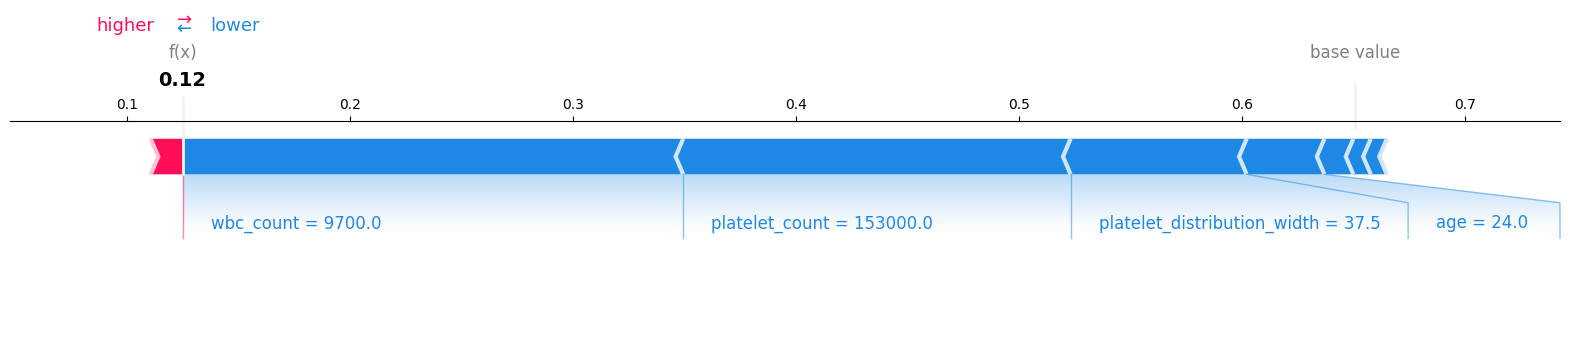

SHAP force plot saved.

PROCESS COMPLETED SUCCESSFULLY


In [ ]:
# ----------------------------------------------------------
# 8. SHAP Force Plot for MAR 20%
# ----------------------------------------------------------
selected_level = 0.20

model = stored_models[selected_level]["model"]
X_test_imp = stored_models[selected_level]["X_test_imp"]

explainer = shap.TreeExplainer(model)
raw_shap = explainer.shap_values(X_test_imp)

# Handle SHAP versions
if isinstance(raw_shap, list):
    shap_values = raw_shap[1]
    base_value = explainer.expected_value[1]

elif len(np.array(raw_shap).shape) == 3:
    shap_values = raw_shap[:, :, 1]
    base_value = explainer.expected_value[1]

else:
    shap_values = raw_shap
    base_value = explainer.expected_value

force_plot = shap.force_plot(
    base_value,
    shap_values[0],
    X_test_imp[0],
    feature_names=feature_names,
    matplotlib=True
)

# shap.save_html(
#     "outputs/plots/randomForest_MAR20_force_plot.html",
#     force_plot
# )

print("\nPROCESS COMPLETED SUCCESSFULLY")